In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

In [3]:
# path = 'Excel/FXN/Data_0701.xlsx'
path = 'Data\FXN_2023\FXN_20230701\cluster_excel\B2_0701_cluster.xlsx'
Data_All = pd.read_excel(path)
Data = Data_All[[
    'Organoids_Volume',
    'Organoids_Volume_Fill',
    'Organoids_Surface',
    'Cavity_Volume',
    'CavityNum',
    'LongAxis',
    'ShortAxis',
    'Wall_Thickness',
    'Sphericity',
]]

In [4]:
# Data = Data.apply(lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)))
scaler = StandardScaler()
Data = scaler.fit_transform(Data)

c:\Users\student13\miniforge3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\student13\miniforge3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\student13\miniforge3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\student13\miniforge3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a m

<function matplotlib.pyplot.show(close=None, block=None)>

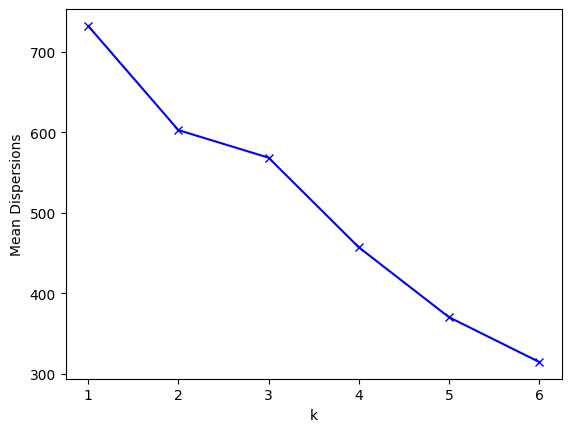

In [5]:
meanDispersions = []
kms = []
for i in range(1,7):
    temp = KMeans(n_clusters=i, init='k-means++', n_init='auto')
    kms.append(temp.fit(Data))
    # 计算平均离差
    m_Disp = sum(np.min(cdist(Data, temp.cluster_centers_, 'euclidean'), axis=1))
    meanDispersions.append(m_Disp)
    
plt.plot(range(1,7), meanDispersions, 'bx-')
plt.xlabel('k')
plt.ylabel('Mean Dispersions')
plt.title('')
plt.show

In [6]:
test = kms[3]

In [8]:
# 聚类模型保存
import pickle
with open('model\Kmeans-scatt.pickle', 'wb') as f:
    pickle.dump(test, f)

In [9]:
# 聚类模型加载
import pickle
with open('model\Kmeans-scatt.pickle', 'rb') as f:
    test = pickle.load(f)

In [ ]:
path1 = 'Data\Test\20230701'
file_ls = os.listdir(path1)
ROOTS1 = [os.path.join(path1, file) for file in file_ls]

path2 = 'Data\Test\20230703'
file_ls = os.listdir(path2)
ROOTS2 = [os.path.join(path2, file) for file in file_ls]

ROOTS = ROOTS1 + ROOTS2

FileNotFoundError: [WinError 3] 系统找不到指定的路径。: 'Data\\Test\x8230701'

In [7]:
Data_All = []
for ROOT in ROOTS:
    DF = pd.read_excel(ROOT)
    Data_All.append(DF)
Data_All = pd.concat(Data_All, ignore_index=True)

In [8]:
Data_All = Data_All.drop(columns='Cluster')
# Data_All.to_excel('ICC005/20230701/ICC005_0701.xlsx', index=False)

In [9]:
# path = 'Data/FXN/20230701/FXN-0701.xlsx'
# Data_All = pd.read_excel(path)
Data = Data_All[[
    'Organoids_Volume',
    'Organoids_Volume_Fill',
    'Organoids_Surface',
    'Cavity_Volume',
    'CavityNum',
    'LongAxis',
    'ShortAxis',
    'Wall_Thickness',
    'Sphericity',
]]
# Data = Data.apply(lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)))
# 数据标准化
scaler = StandardScaler()
Data_Std = scaler.fit_transform(Data)

In [10]:
# 用拟合的模型对新的数据进行聚类
cluster = test.predict(Data_Std)
Data_All.insert(Data_All.shape[1], 'Cluster', cluster) # 将聚类标签添加到 Data_All 中

In [11]:
Data_All.to_excel('GT/fxn-test/fxn_labels.xlsx', index=False) # 将 DataFrame 保存为 Excel

In [ ]:
# 读取 Excel
# path = 'Temp/20230701/ICC005_0701_labels.xlsx'
# Data_All = pd.read_excel(path)

In [ ]:
list = Data_All['Index']
for ROOT in ROOTS:
    p = Path(ROOT)
    name = p.stem
    index_temp = []
    for i in range(len(list)):
        if name in list[i]:
            index_temp.append(True)
        else:
            index_temp.append(False)
    temp = Data_All.loc[index_temp]
    temp.to_excel(ROOT, index=False)
    print('{} Complete!'.format(ROOT))